# Exploratory Data Analysis

## 0. Setup — download the dataset

In [30]:
#Install Kaggle CLI
!pip install -q kaggle

In [31]:
# 2. Trigger the download
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
brain-tumor-mri-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [32]:
# 3. Unzip the images (-n: never overwrite, so re-running this cell doesn't hang on a prompt)
!unzip -qn brain-tumor-mri-dataset.zip -d brain_tumor_data

## 1. Imports

In [33]:
# Everything the EDA needs: paths, random sampling, file hashing, arrays, images, plots.
# No torch/torchvision here — this notebook describes the raw image files, nothing else.
import random
import hashlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

## 2. Config

Dataset path, class names, the random seed, plot colours, and one helper that lists the images in a folder.
Every later section uses these.

In [34]:
# The folder the unzip cell above created, and the four class folders inside it.
# below is the path in colab environment, change it to your local path if you are running it locally.
DATA_ROOT = Path("/content/brain_tumor_data")
CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]
SPLITS = ["Training", "Testing"]

# One seed for every random sample in this notebook, so re-running picks the same images.
# Same value as SEED in src/dataset.py.
SEED = 42

# Fixed colour per class and per split, so the same class looks the same in every figure.
CLASS_COLORS = {"glioma": "#2a78d6", "meningioma": "#eb6834", "notumor": "#1baf7a", "pituitary": "#4a3aa7"}
SPLIT_COLORS = {"Training": "#2a78d6", "Testing": "#eb6834"}

sns.set_theme(style="whitegrid")


def list_images(split, cls):
    """Sorted list of .jpg paths in one folder, e.g. list_images("Training", "glioma")."""
    return sorted((DATA_ROOT / split / cls).glob("*.jpg"))


print("Dataset folder:", DATA_ROOT)

Dataset folder: /content/brain_tumor_data


## 3. Dataset verification

Counts the images in all eight folders (4 classes × 2 splits) and stops with a clear message if one is
missing or empty, so every later section can assume the dataset is complete.

In [35]:
# Count each folder, and fail immediately if the download or unzip went wrong.
counts = {split: {} for split in SPLITS}
for split in SPLITS:
    for cls in CLASSES:
        folder = DATA_ROOT / split / cls
        if not folder.is_dir():
            raise FileNotFoundError(f"Missing folder: {folder}")
        n_images = len(list_images(split, cls))
        if n_images == 0:
            raise ValueError(f"No .jpg images in: {folder}")
        counts[split][cls] = n_images

# Print the counts as a table
print(f"{'Class':<12}{'Training':>10}{'Testing':>10}{'Total':>10}")
for cls in CLASSES:
    train_n, test_n = counts["Training"][cls], counts["Testing"][cls]
    print(f"{cls:<12}{train_n:>10}{test_n:>10}{train_n + test_n:>10}")

train_total = sum(counts["Training"].values())
test_total = sum(counts["Testing"].values())
print(f"{'Total':<12}{train_total:>10}{test_total:>10}{train_total + test_total:>10}")

Class         Training   Testing     Total
glioma            1400       400      1800
meningioma        1400       400      1800
notumor           1400       400      1800
pituitary         1400       400      1800
Total             5600      1600      7200


## 4. Class distribution

The counts from Section 3 as a bar chart: Training and Testing side by side for each class.

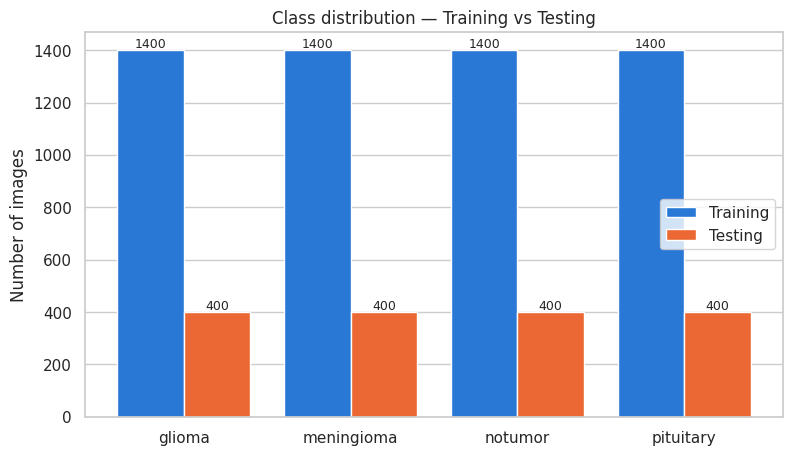

In [36]:
# Count the images again so this cell runs on its own, then draw two bars per class.
counts = {split: {cls: len(list_images(split, cls)) for cls in CLASSES} for split in SPLITS}

x = np.arange(len(CLASSES))  # bar positions: 0, 1, 2, 3
width = 0.4

fig, ax = plt.subplots(figsize=(9, 5))
for i, split in enumerate(SPLITS):
    values = [counts[split][cls] for cls in CLASSES]
    bars = ax.bar(x + (i - 0.5) * width, values, width, label=split, color=SPLIT_COLORS[split])
    ax.bar_label(bars, fontsize=9)  # write the count on top of each bar

ax.set_xticks(x, CLASSES)
ax.set_ylabel("Number of images")
ax.set_title("Class distribution — Training vs Testing")
ax.grid(axis="x", visible=False)  # vertical gridlines would cut through the bars
ax.legend()
plt.show()

## 5. Class imbalance analysis

Imbalance ratio = largest class ÷ smallest class. Rule of thumb used here:
**< 1.5 mild**, **1.5–3 moderate**, **> 3 severe**. The majority-class accuracy is the score a model
would get by always predicting the biggest class — the floor any real model has to beat.

In [37]:
# Ratio and majority-class baseline for each split.
for split in SPLITS:
    counts = {cls: len(list_images(split, cls)) for cls in CLASSES}
    ratio = max(counts.values()) / min(counts.values())
    biggest = max(counts, key=counts.get)  # the class with the most images
    baseline = counts[biggest] / sum(counts.values())

    if ratio == 1:
        verdict = "PERFECTLY BALANCED — every class has the same number of images"
    elif ratio < 1.5:
        verdict = "MILD — classes are close to balanced, no resampling needed"
    elif ratio <= 3:
        verdict = "MODERATE — consider class weights or oversampling"
    else:
        verdict = "SEVERE — resampling or class weights required"

    print(f"{split}")
    print(f"  images per class: {counts}")
    print(f"  imbalance ratio : {ratio:.2f}x  ->  {verdict}")
    print(f"  always predicting '{biggest}' would score {baseline:.1%} accuracy\n")

Training
  images per class: {'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400}
  imbalance ratio : 1.00x  ->  PERFECTLY BALANCED — every class has the same number of images
  always predicting 'glioma' would score 25.0% accuracy

Testing
  images per class: {'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}
  imbalance ratio : 1.00x  ->  PERFECTLY BALANCED — every class has the same number of images
  always predicting 'glioma' would score 25.0% accuracy



## 6. Sample images

Five random Training images per class, one row per class, with each image's original size as its title.

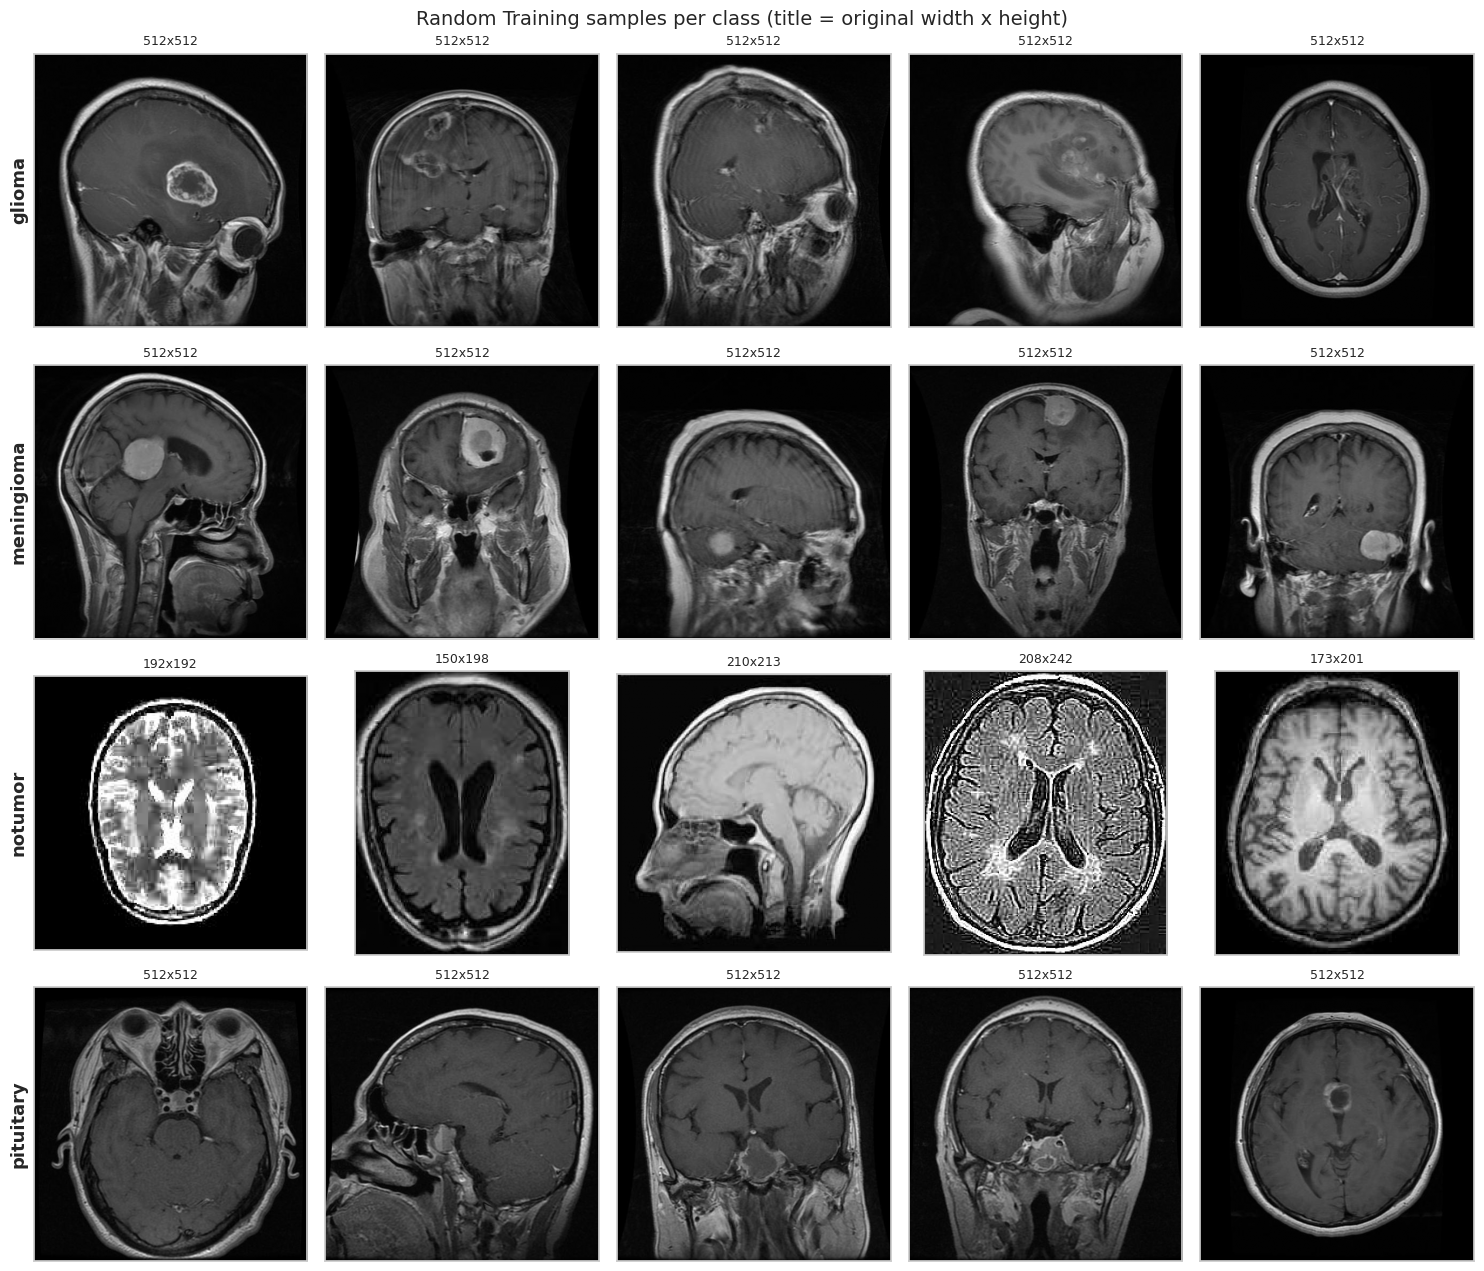

In [38]:
# A visual check that the labels match the images, and a first look at how similar
# the four classes are. Drawn in grayscale, which is what an MRI scan actually is.
random.seed(SEED)

fig, axes = plt.subplots(len(CLASSES), 5, figsize=(15, 13))
for row, cls in enumerate(CLASSES):
    paths = random.sample(list_images("Training", cls), 5)
    for col, path in enumerate(paths):
        ax = axes[row, col]
        with Image.open(path) as img:
            ax.imshow(img.convert("L"), cmap="gray")
            ax.set_title(f"{img.width}x{img.height}", fontsize=9)
        ax.set_xticks([])  # pixel positions are not a meaningful axis
        ax.set_yticks([])
        ax.grid(False)
    axes[row, 0].set_ylabel(cls, fontsize=13, fontweight="bold")  # row label

fig.suptitle("Random Training samples per class (title = original width x height)", fontsize=14)
fig.tight_layout()  # remove the extra white space between the 20 images
plt.show()

## 7. Image size verification

Opens 10 random Training images per class and collects the distinct `(width, height)` values.
A CNN needs one fixed input size, so mixed sizes mean a resize step is mandatory.

In [39]:
# Image.open reads only the file header, so checking .size is cheap.
random.seed(SEED)

all_sizes = set()
for cls in CLASSES:
    sizes = set()
    for path in random.sample(list_images("Training", cls), 10):
        with Image.open(path) as img:
            sizes.add(img.size)  # (width, height)
    all_sizes.update(sizes)
    print(f"{cls:<12} {sorted(sizes)}")

if len(all_sizes) > 1:
    print(f"\nWARNING: {len(all_sizes)} different sizes in the sample — every image must be "
          f"resized to one common size (224x224 in src/transforms.py) before batching.")
else:
    print("\nAll sampled images have the same size.")

glioma       [(512, 512)]
meningioma   [(318, 354), (416, 395), (512, 512)]
notumor      [(173, 201), (218, 231), (225, 225), (227, 222), (230, 282), (235, 227), (236, 213), (236, 236), (420, 280), (630, 630)]
pituitary    [(512, 512), (1335, 1302)]



## 8. Pixel intensity distribution

Grayscale histograms of 50 random Training images per class, one line per class on the same axes.
`density=True` makes the classes comparable even though they contain different numbers of pixels.
The y-axis is logarithmic because black background pixels outnumber tissue pixels by a wide margin
and would otherwise flatten the rest of the curve.

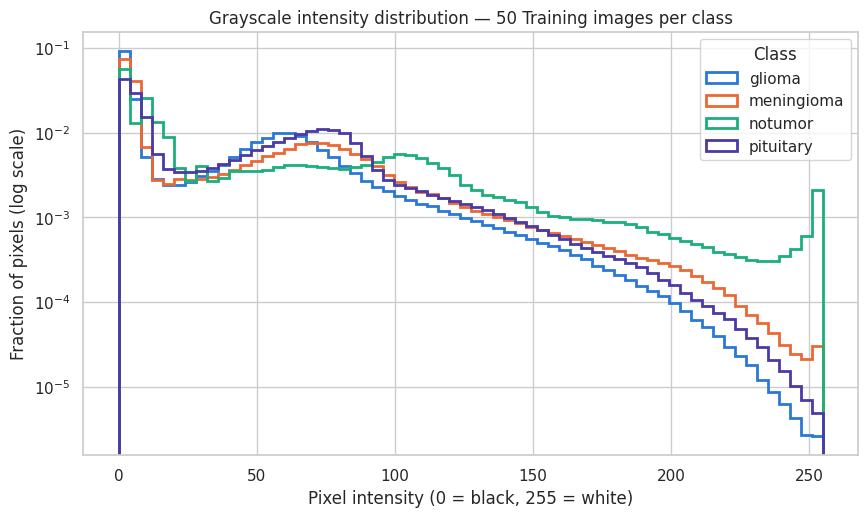

In [40]:
# Load 50 images per class as grayscale, stack all their pixels, and histogram them.
random.seed(SEED)

fig, ax = plt.subplots(figsize=(10, 5.5))
for cls in CLASSES:
    pixels = []
    for path in random.sample(list_images("Training", cls), 50):
        with Image.open(path) as img:
            pixels.append(np.array(img.convert("L")).ravel())  # 2-D image -> 1-D pixel list
    pixels = np.concatenate(pixels)
    ax.hist(pixels, bins=64, range=(0, 255), density=True, histtype="step",
            linewidth=2, label=cls, color=CLASS_COLORS[cls])

ax.set_yscale("log")
ax.set_xlabel("Pixel intensity (0 = black, 255 = white)")
ax.set_ylabel("Fraction of pixels (log scale)")
ax.set_title("Grayscale intensity distribution — 50 Training images per class")
ax.legend(title="Class")
plt.show()

## 9. RGB channel means

Mean R, G and B value of 50 random Training images per class. MRI is a single-channel modality, so if
the JPEGs are grayscale stored as 3-channel files the three bars in each group will be identical.

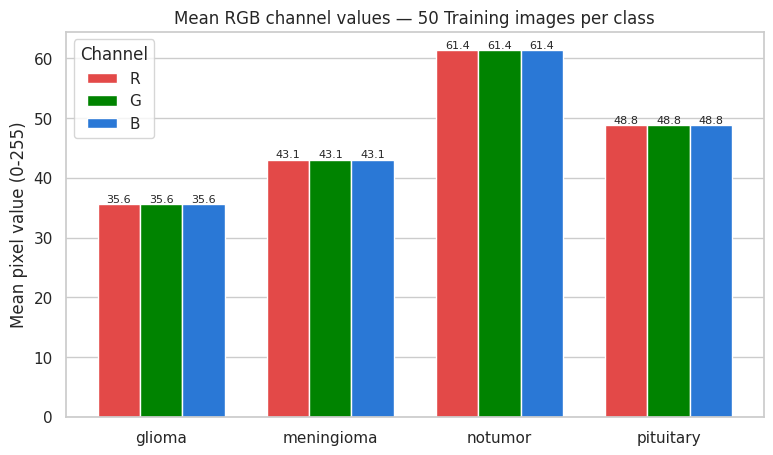

glioma       R= 35.61  G= 35.61  B= 35.61
meningioma   R= 43.09  G= 43.09  B= 43.09
notumor      R= 61.38  G= 61.37  B= 61.40
pituitary    R= 48.82  G= 48.82  B= 48.82


In [41]:
# Average each image over all its pixels to get one (R, G, B) triple, then average
# those triples per class.
random.seed(SEED)

means = {}
for cls in CLASSES:
    per_image = []
    for path in random.sample(list_images("Training", cls), 50):
        with Image.open(path) as img:
            rgb = np.array(img.convert("RGB"))          # shape (height, width, 3)
        per_image.append(rgb.reshape(-1, 3).mean(axis=0))  # mean of R, G, B
    means[cls] = np.mean(per_image, axis=0)

x = np.arange(len(CLASSES))
width = 0.25
channels = ["R", "G", "B"]
channel_colors = ["#e34948", "#008300", "#2a78d6"]

fig, ax = plt.subplots(figsize=(9, 5))
for i, (channel, color) in enumerate(zip(channels, channel_colors)):
    values = [means[cls][i] for cls in CLASSES]
    bars = ax.bar(x + (i - 1) * width, values, width, label=channel, color=color)
    ax.bar_label(bars, fmt="%.1f", fontsize=8)

ax.set_xticks(x, CLASSES)
ax.set_ylabel("Mean pixel value (0-255)")
ax.set_title("Mean RGB channel values — 50 Training images per class")
ax.grid(axis="x", visible=False)
ax.legend(title="Channel")
plt.show()

# Equal R, G and B means the file has three copies of the same grayscale channel.
for cls in CLASSES:
    r, g, b = means[cls]
    print(f"{cls:<12} R={r:6.2f}  G={g:6.2f}  B={b:6.2f}")

## 10. Duplicate & leakage check

Two files with the same content have the same MD5 hash, so grouping every image by its hash finds exact
duplicates. A duplicate that sits in **both** splits is data leakage: the model would be tested on an
image it trained on, which inflates the test score. Only byte-identical copies are found this way;
a re-saved or resized copy would need a perceptual hash.

In [42]:
# Hash every image and group the file names by hash.
hashes = {}
for split in SPLITS:
    for cls in CLASSES:
        for path in list_images(split, cls):
            digest = hashlib.md5(path.read_bytes()).hexdigest()
            hashes.setdefault(digest, []).append(f"{split}/{cls}/{path.name}")

# Any hash with more than one file is a duplicate group
duplicates = [files for files in hashes.values() if len(files) > 1]
leaks = [files for files in duplicates
         if any(f.startswith("Training") for f in files) and any(f.startswith("Testing") for f in files)]

print(f"Images checked:           {sum(len(files) for files in hashes.values())}")
print(f"Unique images:            {len(hashes)}")
print(f"Duplicate groups:         {len(duplicates)}")
print(f"Redundant copies:         {sum(len(files) - 1 for files in duplicates)}")
print(f"Training/Testing overlap: {len(leaks)}")

# Where the duplicates sit decides what to do about them: inside Training they can land on
# both sides of the train/validation split, and across two class folders they are a label error.
inside_training = [files for files in duplicates if all(f.startswith("Training") for f in files)]
inside_testing = [files for files in duplicates if all(f.startswith("Testing") for f in files)]
cross_class = [files for files in duplicates if len({f.split("/")[1] for f in files}) > 1]

print(f"  inside Training:        {len(inside_training)}")
print(f"  inside Testing:         {len(inside_testing)}")
print(f"  same image, 2 classes:  {len(cross_class)}")

# Print the label conflicts — the same scan filed under two different diagnoses
for files in cross_class[:5]:
    print("   ", "  |  ".join(files))

Images checked:           7200
Unique images:            7013
Duplicate groups:         153
Redundant copies:         187
Training/Testing overlap: 0
  inside Training:        138
  inside Testing:         15
  same image, 2 classes:  0
